# Election Analysis and Prediction

This notebook studies Canadian federal election patterns using vote-share time series, party-level trend structure, and province-level participation indicators. 
The analysis first standardizes historical inputs, then produces descriptive outputs that support interpretation of party momentum and electoral participation across time and geography.

Prediction in this notebook is scenario-oriented rather than a single deterministic forecast. 
The workflow emphasizes transparent data checks, comparable visual diagnostics, and interpretable summary tables so that any projection assumptions can be inspected and revised explicitly.

Core aims:
- Build a reproducible cleaned election dataset for longitudinal comparison.
- Quantify and visualize party vote-share evolution and recent-cycle structure.
- Support cautious prediction by linking trend evidence to clear assumptions.

Execution note: run sections in order, because some helper function names are reused across modules.


In [9]:
import subprocess
import sys

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-U",
    "pandas",
    "numpy",
    "matplotlib",
    "openpyxl",
])



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


0

## Election Workflow

**Research Objective**
This section constructs a longitudinal profile of Canadian federal party vote shares from 2000 to 2025 and compares provincial participation through votes versus registered electors.

**Methodological Approach**
The procedure standardizes party labels, validates annual vote-share totals, generates trend and heatmap visualizations, and creates a province-level multi-panel comparison.

**Interpretation Scope**
The outputs support both temporal interpretation of national party dynamics and cross-province participation structure in the same analytical frame.

**Source Links**
- https://www.sfu.ca/~aheard/elections/1867-present.html
- https://researchbriefings.files.parliament.uk/documents/CBP-10244/CBP-10244.pdf

**Expected Outputs**
- `outputs/fig1_trend.png`
- `outputs/fig2_bar_2025.png`
- `outputs/fig3_heatmap_2021.png`
- `outputs/fig3_heatmap_2025.png`
- `outputs/fig4_votes_vs_electors_by_province.png`
- `outputs/national_vote_share_clean.csv`
- `outputs/national_vote_share_sumcheck.csv`


In [10]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from pathlib import Path

DATASET_URL_2000_2021 = "https://www.sfu.ca/~aheard/elections/1867-present.html"
DATASET_URL_2025 = "https://researchbriefings.files.parliament.uk/documents/CBP-10244/CBP-10244.pdf"

def find_project_root(marker):
    here = Path.cwd().resolve()
    for candidate in [here] + list(here.parents):
        if (candidate / marker).exists():
            return candidate
    return here

PROJECT_ROOT = find_project_root("canada_federal_vote_share_2000_2025.csv")

INPUT_CSV = PROJECT_ROOT / "canada_federal_vote_share_2000_2025.csv"
OUT_DIR = PROJECT_ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

PROV_INPUT_CSV = PROJECT_ROOT / "canada_province_votes_electors_2000_2025.csv"
KAGGLE_DIR = PROJECT_ROOT / "kaggle_canada_election"


def canon_party(p):
    s = str(p).strip().lower()
    s = re.sub(r"\s+", " ", s)
    if "liberal" in s:
        return "Liberal"
    if "conservative" in s or "canadian alliance" in s or "progressive conservative" in s:
        return "Conservative"
    if "new democratic" in s or "(ndp)" in s or s == "ndp":
        return "NDP"
    if "bloc" in s:
        return "Bloc Québécois"
    if "green" in s:
        return "Green"
    if "people" in s:
        return "People's"
    if "other" in s:
        return "Others"
    return "Others"

def detect_col(df, candidates):
    cols = {c.lower(): c for c in df.columns}
    for k in candidates:
        if k in cols:
            return cols[k]
    for c in df.columns:
        cl = str(c).lower()
        for k in candidates:
            if k in cl:
                return c
    return None

def build_year_map_from_election_info(path):
    info = pd.read_csv(path, low_memory=False)
    c_eid = detect_col(info, ["election_id"])
    c_evt = detect_col(info, ["event_number"])
    c_date = detect_col(info, ["election_date", "date", "event_date"])
    if c_eid is None:
        raise RuntimeError(f"Election info missing election_id. Columns: {info.columns.tolist()}")
    if c_date is not None:
        dt = pd.to_datetime(info[c_date], errors="coerce")
        info = info.assign(_year=dt.dt.year)
        m = info[[c_eid, "_year"]].dropna().drop_duplicates()
        year_map = dict(zip(m[c_eid].astype(str), m["_year"].astype(int)))
        if year_map:
            return year_map
    if c_evt is not None:
        ev = pd.to_numeric(info[c_evt], errors="coerce")
        info = info.assign(_ev=ev)
        evs = sorted([int(x) for x in info["_ev"].dropna().unique().tolist()])
        known = [2000, 2004, 2006, 2008, 2011, 2015, 2019, 2021]
        year_map = {}
        if len(evs) == len(known):
            emap = dict(zip(evs, known))
            for _, r in info[[c_eid, "_ev"]].dropna().drop_duplicates().iterrows():
                year_map[str(r[c_eid])] = emap.get(int(r["_ev"]), np.nan)
            year_map = {k: int(v) for k, v in year_map.items() if pd.notna(v)}
            if year_map:
                return year_map
    raise RuntimeError(f"Cannot build year map from election info. Columns: {info.columns.tolist()}")

def build_prov_votes_electors_from_kaggle(kdir):
    ei = os.path.join(kdir, "Election Information.CSV")
    results = os.path.join(kdir, "Results.csv")
    poll = os.path.join(kdir, "Poll Details.csv")
    rid = os.path.join(kdir, "Ridings.csv")
    for fp in [ei, results, poll, rid]:
        if not os.path.exists(fp):
            raise RuntimeError(f"Missing required Kaggle file: {fp}")

    year_map = build_year_map_from_election_info(ei)

    ridings = pd.read_csv(rid, low_memory=False)
    rd_ed = detect_col(ridings, ["electoral_district_number", "circonscription"])
    rd_prov = detect_col(ridings, ["canadian_province", "province"])
    if rd_ed is None or rd_prov is None:
        raise RuntimeError(f"Ridings missing ed/province columns. Columns: {ridings.columns.tolist()}")
    rid_map = ridings[[rd_ed, rd_prov]].dropna().drop_duplicates().copy()
    rid_map.columns = ["ed_num", "province"]
    rid_map["ed_num"] = rid_map["ed_num"].astype(str).str.strip()

    poll_df = pd.read_csv(poll, low_memory=False, usecols=lambda c: True)
    p_eid = detect_col(poll_df, ["election_id"])
    p_ed = detect_col(poll_df, ["electoral_district_number", "circonscription"])
    p_elec = detect_col(poll_df, ["electors", "électeurs"])
    if p_eid is None or p_ed is None or p_elec is None:
        raise RuntimeError(f"Poll Details missing required columns. Columns: {poll_df.columns.tolist()}")
    poll_df = poll_df[[p_eid, p_ed, p_elec]].copy()
    poll_df.columns = ["election_id", "ed_num", "electors"]
    poll_df["election_id"] = poll_df["election_id"].astype(str).str.strip()
    poll_df["ed_num"] = poll_df["ed_num"].astype(str).str.strip()
    poll_df["electors"] = pd.to_numeric(poll_df["electors"], errors="coerce")
    poll_df = poll_df.dropna(subset=["electors"])
    electors_by_ed = poll_df.groupby(["election_id", "ed_num"], as_index=False)["electors"].sum()

    res_df = pd.read_csv(results, low_memory=False, usecols=lambda c: True)
    r_eid = detect_col(res_df, ["election_id"])
    r_ed = detect_col(res_df, ["electoral_district_number", "circonscription"])
    r_votes = detect_col(res_df, ["candidate_poll_votes_count", "votes"])
    if r_eid is None or r_ed is None or r_votes is None:
        raise RuntimeError(f"Results missing required columns. Columns: {res_df.columns.tolist()}")
    res_df = res_df[[r_eid, r_ed, r_votes]].copy()
    res_df.columns = ["election_id", "ed_num", "votes"]
    res_df["election_id"] = res_df["election_id"].astype(str).str.strip()
    res_df["ed_num"] = res_df["ed_num"].astype(str).str.strip()
    res_df["votes"] = pd.to_numeric(res_df["votes"], errors="coerce")
    res_df = res_df.dropna(subset=["votes"])
    votes_by_ed = res_df.groupby(["election_id", "ed_num"], as_index=False)["votes"].sum()

    m = votes_by_ed.merge(electors_by_ed, on=["election_id", "ed_num"], how="inner")
    m = m.merge(rid_map, on="ed_num", how="left")
    m["year"] = m["election_id"].map(year_map)
    m = m.dropna(subset=["province", "year"]).copy()
    m["year"] = m["year"].astype(int)

    out = m.groupby(["year", "province"], as_index=False)[["votes", "electors"]].sum()
    out = out.sort_values(["province", "year"])
    return out

def heatmap_single_year(df_clean, year, order):
    wide = df_clean.pivot(index="Year", columns="Party", values="VoteShare").fillna(0)
    wide = wide.reindex(columns=[c for c in order if c in wide.columns])
    if year not in wide.index:
        raise RuntimeError(f"Year {year} not found for heatmap.")
    row = wide.loc[[year]].copy()
    plt.figure(figsize=(12, 3))
    im = plt.imshow(row.values, aspect="auto")
    plt.yticks([0], [str(year)])
    plt.xticks(range(len(row.columns)), row.columns, rotation=45, ha="right")
    plt.xlabel("Party")
    plt.ylabel("Year")
    plt.title(f"{year} vote share heatmap (single-year)")
    plt.colorbar(im, label="Vote share (%)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"fig3_heatmap_{year}.png"), dpi=160)
    plt.close()

def main():
    df = pd.read_csv(INPUT_CSV)

    c_year = detect_col(df, ["year"])
    c_party = detect_col(df, ["party"])
    c_share = detect_col(df, ["voteshare", "vote_share", "share", "pct", "percent", "percentage"])
    c_source = detect_col(df, ["source", "url"])

    if c_year is None or c_party is None or c_share is None:
        raise RuntimeError(f"Missing required columns. Found: {df.columns.tolist()}")

    df = df[[c_year, c_party, c_share] + ([c_source] if c_source else [])].copy()
    df.columns = ["Year", "Party", "VoteShare"] + (["Source"] if c_source else [])

    df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype("Int64")
    df["VoteShare"] = pd.to_numeric(df["VoteShare"], errors="coerce")
    df = df.dropna(subset=["Year", "Party", "VoteShare"]).copy()
    df["Year"] = df["Year"].astype(int)

    df["Party_Canon"] = df["Party"].map(canon_party)
    df_clean = df.groupby(["Year", "Party_Canon"], as_index=False)["VoteShare"].sum()
    df_clean = df_clean.rename(columns={"Party_Canon": "Party"})
    df_clean.to_csv(os.path.join(OUT_DIR, "national_vote_share_clean.csv"), index=False)

    check = df_clean.groupby("Year")["VoteShare"].sum().reset_index()
    check["diff_from_100"] = check["VoteShare"] - 100.0
    check.to_csv(os.path.join(OUT_DIR, "national_vote_share_sumcheck.csv"), index=False)

    order = ["Liberal", "Conservative", "NDP", "Bloc Québécois", "Green", "People's", "Others"]
    wide = df_clean.pivot(index="Year", columns="Party", values="VoteShare").fillna(0)
    wide = wide.reindex(columns=[c for c in order if c in wide.columns])

    ax = wide.plot(figsize=(11, 5))
    ax.set_xlabel("Year")
    ax.set_ylabel("Vote share (%)")
    ax.set_title("Canada federal election: national vote share (2000–2025)")
    ax.grid(True)

    election_years = sorted(wide.index.unique().tolist())
    ymin, ymax = ax.get_ylim()
    for y in election_years:
        ax.vlines(x=y, ymin=ymin, ymax=ymax, linestyles="--", linewidth=1.0)
        ax.text(
            y, -0.10, f"{y} election",
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=7,
            rotation=90,
            clip_on=False
        )
    ax.set_ylim(ymin, ymax)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.30)
    plt.savefig(os.path.join(OUT_DIR, "fig1_trend.png"), dpi=160)
    plt.close()

    snap = df_clean[df_clean["Year"] == 2025].sort_values("VoteShare", ascending=False).copy()
    plt.figure(figsize=(10, 5))
    plt.bar(snap["Party"], snap["VoteShare"])
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Party")
    plt.ylabel("Vote share (%)")
    plt.title("2025 national vote share by party")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "fig2_bar_2025.png"), dpi=160)
    plt.close()

    heatmap_single_year(df_clean, 2021, order)
    heatmap_single_year(df_clean, 2025, order)

    prov_df = None
    if os.path.exists(PROV_INPUT_CSV):
        prov_df = pd.read_csv(PROV_INPUT_CSV, low_memory=False)
        py = detect_col(prov_df, ["year"])
        pp = detect_col(prov_df, ["province", "prov"])
        pv = detect_col(prov_df, ["votes", "voters", "ballots", "votes_cast"])
        pe = detect_col(prov_df, ["electors", "eligible", "registered", "population"])
        if py is None or pp is None or pv is None or pe is None:
            raise RuntimeError(f"Province CSV missing columns. Found: {prov_df.columns.tolist()}")
        prov_df = prov_df[[py, pp, pv, pe]].copy()
        prov_df.columns = ["year", "province", "votes", "electors"]
        prov_df["year"] = pd.to_numeric(prov_df["year"], errors="coerce").astype("Int64")
        prov_df["votes"] = pd.to_numeric(prov_df["votes"], errors="coerce")
        prov_df["electors"] = pd.to_numeric(prov_df["electors"], errors="coerce")
        prov_df = prov_df.dropna(subset=["year", "province", "votes", "electors"]).copy()
        prov_df["year"] = prov_df["year"].astype(int)
    else:
        if os.path.isdir(KAGGLE_DIR):
            prov_df = build_prov_votes_electors_from_kaggle(KAGGLE_DIR)
            prov_df.to_csv(os.path.join(OUT_DIR, "province_votes_electors_from_kaggle.csv"), index=False)
        else:
            raise RuntimeError(
                f"Need {PROV_INPUT_CSV} or Kaggle folder {KAGGLE_DIR}/ with Results.csv, Poll Details.csv, Ridings.csv, Election Information.CSV"
            )

    prov_df = prov_df.sort_values(["province", "year"]).copy()
    provinces = sorted(prov_df["province"].dropna().unique().tolist())
    n = len(provinces)
    cols = 4
    rows = int(np.ceil(n / cols))

    fig = plt.figure(figsize=(14, 3.2 * rows))
    for i, prov in enumerate(provinces):
        ax = fig.add_subplot(rows, cols, i + 1)
        d = prov_df[prov_df["province"] == prov].sort_values("year").copy()
        x = d["year"].values
        y_votes = (d["votes"].values / 1_000_000.0)
        y_elec = (d["electors"].values / 1_000_000.0)
        ax.plot(x, y_votes, label="Votes (M)")
        ax.plot(x, y_elec, label="Electors (M)")
        ax.set_title(str(prov))
        ax.set_xlabel("Year")
        ax.set_ylabel("Millions")
        ax.grid(True)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "fig4_votes_vs_electors_by_province.png"), dpi=160)
    plt.close()

    print("Saved:")
    print(os.path.join(OUT_DIR, "fig1_trend.png"))
    print(os.path.join(OUT_DIR, "fig2_bar_2025.png"))
    print(os.path.join(OUT_DIR, "fig3_heatmap_2021.png"))
    print(os.path.join(OUT_DIR, "fig3_heatmap_2025.png"))
    print(os.path.join(OUT_DIR, "fig4_votes_vs_electors_by_province.png"))
    print(os.path.join(OUT_DIR, "national_vote_share_clean.csv"))
    print(os.path.join(OUT_DIR, "national_vote_share_sumcheck.csv"))
    if os.path.exists(os.path.join(OUT_DIR, "province_votes_electors_from_kaggle.csv")):
        print(os.path.join(OUT_DIR, "province_votes_electors_from_kaggle.csv"))
    print("Dataset URLs:")
    print(DATASET_URL_2000_2021)
    print(DATASET_URL_2025)

if __name__ == "__main__":
    main()



Saved:
/Users/hopan186/Downloads/fyp/fypp/outputs/fig1_trend.png
/Users/hopan186/Downloads/fyp/fypp/outputs/fig2_bar_2025.png
/Users/hopan186/Downloads/fyp/fypp/outputs/fig3_heatmap_2021.png
/Users/hopan186/Downloads/fyp/fypp/outputs/fig3_heatmap_2025.png
/Users/hopan186/Downloads/fyp/fypp/outputs/fig4_votes_vs_electors_by_province.png
/Users/hopan186/Downloads/fyp/fypp/outputs/national_vote_share_clean.csv
/Users/hopan186/Downloads/fyp/fypp/outputs/national_vote_share_sumcheck.csv
/Users/hopan186/Downloads/fyp/fypp/outputs/province_votes_electors_from_kaggle.csv
Dataset URLs:
https://www.sfu.ca/~aheard/elections/1867-present.html
https://researchbriefings.files.parliament.uk/documents/CBP-10244/CBP-10244.pdf


## 2025 Prediction vs Actual

This section uses a **Bayesian hierarchical random-walk time-series model** (Gibbs sampling) trained on elections before 2025 to predict the 2025 national party vote shares.

Data sources used in this cell:
- Historical elections (downloaded in-cell): `https://www.sfu.ca/~aheard/elections/1867-present.html`
- 2025 holdout actual result (local file): `canada_federal_vote_share_2000_2025.csv`

New outputs:
- `outputs/sfu_historical_vote_share_1867_2021.csv`
- `outputs/prediction_2025_vs_actual.csv`
- `outputs/fig5_predicted_vs_actual_2025.png`


Saved:
/Users/hopan186/Downloads/fyp/fypp/outputs/sfu_historical_vote_share_1867_2021.csv
/Users/hopan186/Downloads/fyp/fypp/outputs/prediction_2025_vs_actual.csv
/Users/hopan186/Downloads/fyp/fypp/outputs/fig5_predicted_vs_actual_2025.png
Model: Bayesian hierarchical random walk (Gibbs sampler)
Posterior draws: 2000
2025 MAE: 5.94 percentage points
2025 RMSE: 7.41 percentage points
Source URL used:
https://www.sfu.ca/~aheard/elections/1867-present.html


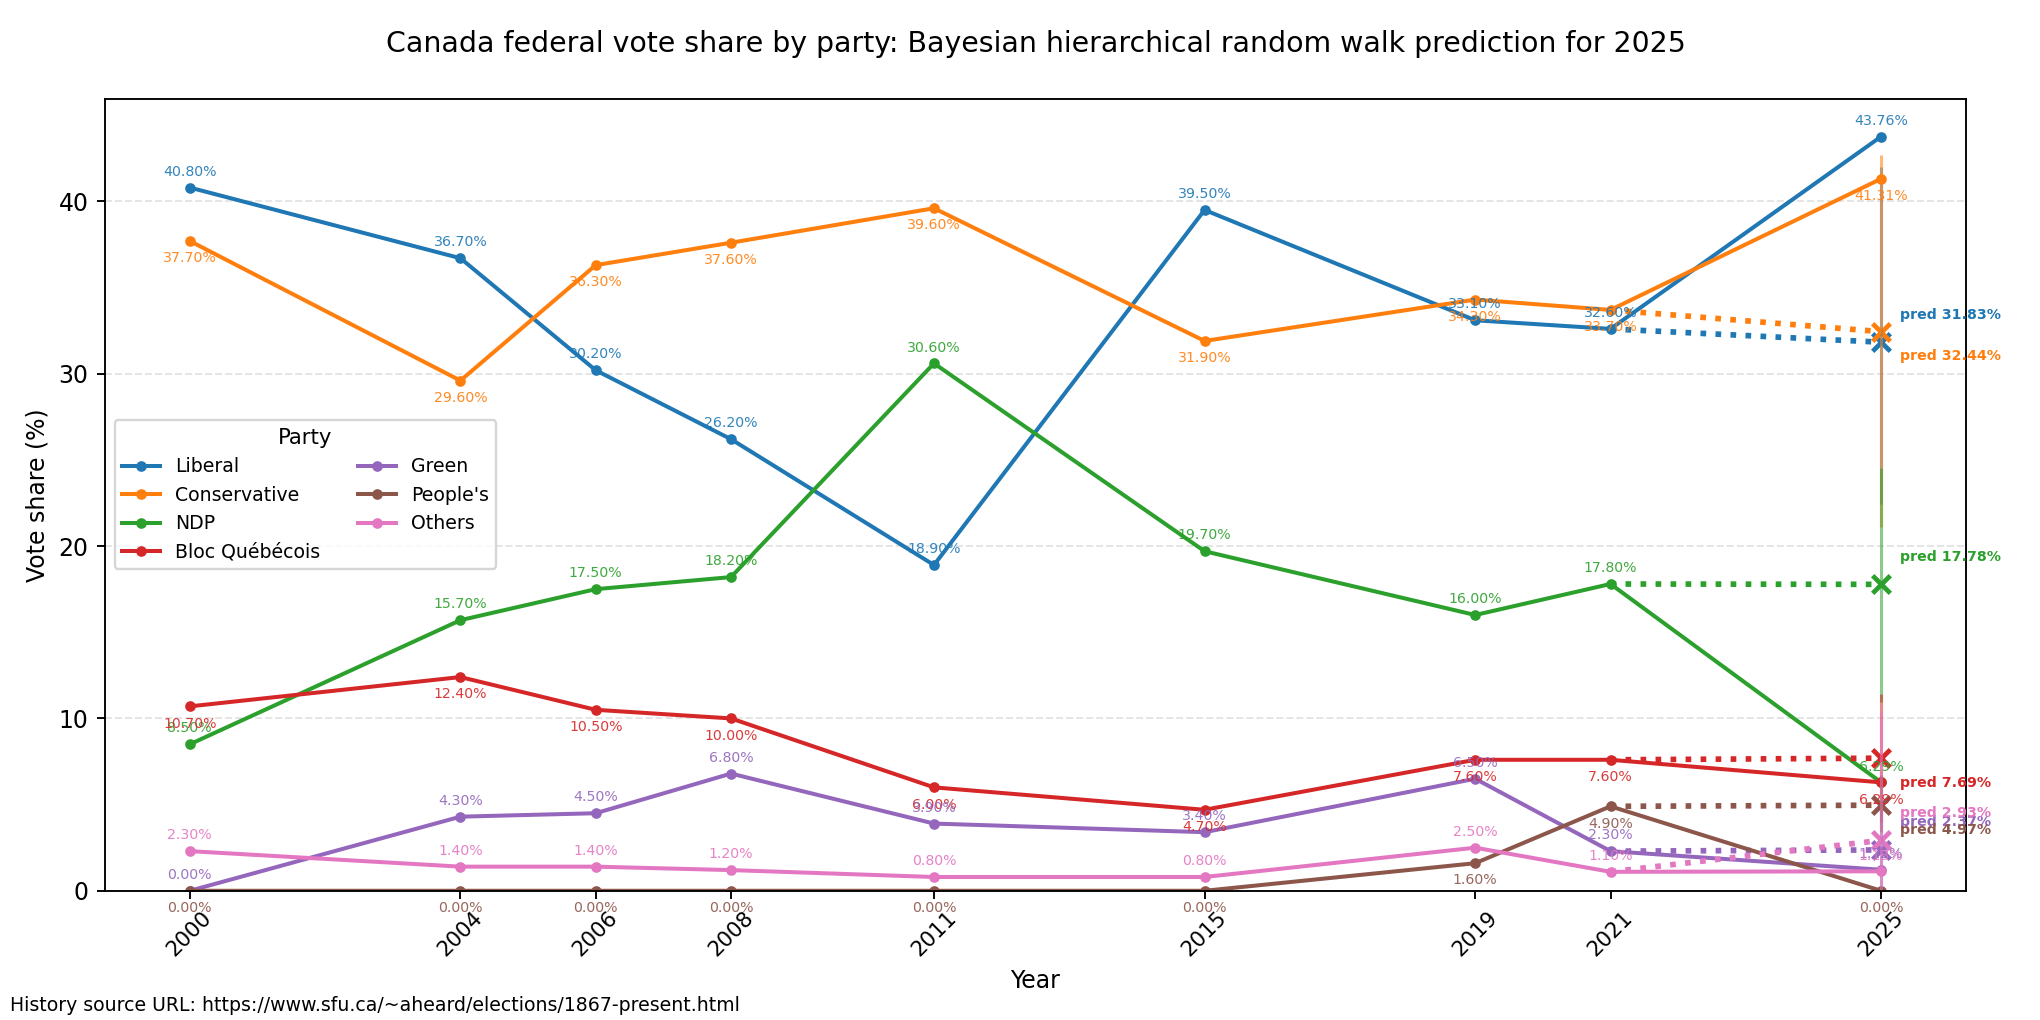

In [11]:
import importlib
import re
import subprocess
import sys
from io import StringIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import Image, display
except Exception:
    Image = None
    display = None


def _ensure_module(module_name, pip_name=None):
    try:
        importlib.import_module(module_name)
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name or module_name])


_ensure_module("requests", "requests")
_ensure_module("lxml", "lxml")
_ensure_module("html5lib", "html5lib")

import requests


def _find_root(marker="canada_federal_vote_share_2000_2025.csv"):
    here = Path.cwd().resolve()
    for candidate in [here] + list(here.parents):
        if (candidate / marker).exists():
            return candidate
    return here


def _detect_col(df, candidates):
    cols = {str(c).lower(): c for c in df.columns}
    for k in candidates:
        if k in cols:
            return cols[k]
    for c in df.columns:
        cl = str(c).lower()
        for k in candidates:
            if k in cl:
                return c
    return None


def _canon_party(name):
    s = str(name).strip().lower()
    s = re.sub(r"\s+", " ", s)

    if "liberal" in s:
        return "Liberal"

    conservative_keys = ["conservative", "canadian alliance", "reform", "national government", "unionist"]
    if any(k in s for k in conservative_keys):
        return "Conservative"

    ndp_keys = ["new democratic", " ndp", "(ndp)", "co-operative commonwealth", "cooperative commonwealth", "ccf"]
    if any(k in s for k in ndp_keys) or s == "ndp":
        return "NDP"

    if "bloc" in s:
        return "Bloc Québécois"

    if "green" in s:
        return "Green"

    if "people" in s and "party" in s:
        return "People's"

    if "other" in s or "independent" in s:
        return "Others"

    return "Others"


def _parse_pct(x):
    if pd.isna(x):
        return np.nan
    s = str(x).replace(" ", " ").strip()
    if not s or s.lower() == "nan":
        return np.nan
    m = re.search(r"-?\d+(?:\.\d+)?", s.replace(",", ""))
    if not m:
        return np.nan
    return float(m.group(0))


def _download_sfu_history(url):
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()
    text = resp.content.decode(resp.encoding or "latin-1", errors="ignore")

    tables = pd.read_html(StringIO(text))
    table = None
    for t in tables:
        if any("Popular Vote" in str(c) for c in t.columns):
            table = t.copy()
            break
    if table is None:
        raise RuntimeError("Could not find the SFU popular-vote table on the source page.")

    col_party = next(c for c in table.columns if "Election" in str(c))
    col_vote = next(c for c in table.columns if "Popular Vote" in str(c))

    rows = []
    current_year = None
    for _, r in table[[col_party, col_vote]].iterrows():
        label = str(r[col_party]).replace(" ", " ").strip()
        vote = _parse_pct(r[col_vote])

        if not label or label.lower() == "nan":
            continue

        ymatch = re.match(r"^(18|19|20)\d{2}", label)
        if ymatch:
            current_year = int(ymatch.group(0))
            continue

        low = label.lower()
        # Exclude non-party summary rows such as government/opposition summaries.
        if (
            low.startswith("election")
            or low.startswith("government")
            or low.startswith("opposition")
            or low.startswith("total")
            or "government--" in low
            or "opposition--" in low
            or "minority--" in low
            or "majority--" in low
        ):
            continue

        if current_year is None or pd.isna(vote):
            continue

        if vote < 0 or vote > 100:
            continue

        rows.append({"Year": current_year, "Party": label, "VoteShare": float(vote), "Source": url})

    out = pd.DataFrame(rows)
    out = out[(out["Year"] >= 1867) & (out["Year"] <= 2021)].copy()
    return out


def _fit_hierarchical_rw_gibbs(y_scaled, x, n_iter=12000, burn=4000, thin=4, seed=42):
    rng = np.random.default_rng(seed)

    p_count, t_count = y_scaled.shape

    # Priors for hierarchical drift + party-level innovation variance.
    s_mu2 = 4.0
    a_tau, b_tau = 2.0, 0.5
    a_sig, b_sig = 2.5, 1.0

    drift = np.array([np.sum(x * y_scaled[p]) / np.sum(x * x) for p in range(p_count)], dtype=float)
    sigma2 = np.array([np.var(y_scaled[p] - x * drift[p]) + 1e-3 for p in range(p_count)], dtype=float)

    mu0 = float(np.mean(drift))
    tau2 = float(np.var(drift) + 0.1)

    drift_draws = []
    sigma2_draws = []

    for it in range(n_iter):
        for p in range(p_count):
            y = y_scaled[p]

            prec = np.sum((x * x) / sigma2[p]) + (1.0 / tau2)
            var = 1.0 / prec
            mean = var * (np.sum((x * y) / sigma2[p]) + (mu0 / tau2))
            drift[p] = rng.normal(mean, np.sqrt(var))

            resid = y - (x * drift[p])
            shape = a_sig + (t_count / 2.0)
            scale = b_sig + 0.5 * np.sum(resid * resid)
            sigma2[p] = 1.0 / rng.gamma(shape, 1.0 / scale)

        prec_mu = (p_count / tau2) + (1.0 / s_mu2)
        var_mu = 1.0 / prec_mu
        mean_mu = var_mu * (np.sum(drift) / tau2)
        mu0 = rng.normal(mean_mu, np.sqrt(var_mu))

        shape_tau = a_tau + (p_count / 2.0)
        scale_tau = b_tau + 0.5 * np.sum((drift - mu0) ** 2)
        tau2 = 1.0 / rng.gamma(shape_tau, 1.0 / scale_tau)

        if it >= burn and ((it - burn) % thin == 0):
            drift_draws.append(drift.copy())
            sigma2_draws.append(sigma2.copy())

    return np.asarray(drift_draws), np.asarray(sigma2_draws)


project_root = _find_root()
out_dir = project_root / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)

HIST_URL = "https://www.sfu.ca/~aheard/elections/1867-present.html"
hist_cache_csv = out_dir / "sfu_historical_vote_share_1867_2021.csv"

if hist_cache_csv.exists():
    hist_raw = pd.read_csv(hist_cache_csv)
else:
    hist_raw = _download_sfu_history(HIST_URL)
    hist_raw.to_csv(hist_cache_csv, index=False)

# Refresh cache if legacy parse issues are present (e.g., negative or >100 shares).
if ((hist_raw["VoteShare"] < 0) | (hist_raw["VoteShare"] > 100)).any():
    hist_raw = _download_sfu_history(HIST_URL)
    hist_raw.to_csv(hist_cache_csv, index=False)

hist = hist_raw.copy()
hist["Party"] = hist["Party"].map(_canon_party)
hist = hist.groupby(["Year", "Party"], as_index=False)["VoteShare"].sum()

local_csv = project_root / "canada_federal_vote_share_2000_2025.csv"
raw_2025 = pd.read_csv(local_csv)

y_col = _detect_col(raw_2025, ["year"])
p_col = _detect_col(raw_2025, ["party"])
v_col = _detect_col(raw_2025, ["voteshare", "vote_share", "share", "pct", "percent", "percentage"])
if y_col is None or p_col is None or v_col is None:
    raise RuntimeError(f"Missing required columns in {local_csv}. Found: {raw_2025.columns.tolist()}")

holdout = raw_2025[[y_col, p_col, v_col]].copy()
holdout.columns = ["Year", "Party", "VoteShare"]
holdout["Year"] = pd.to_numeric(holdout["Year"], errors="coerce").astype("Int64")
holdout["VoteShare"] = pd.to_numeric(holdout["VoteShare"], errors="coerce")
holdout = holdout.dropna(subset=["Year", "Party", "VoteShare"]).copy()
holdout["Year"] = holdout["Year"].astype(int)
holdout["Party"] = holdout["Party"].map(_canon_party)
holdout_2025 = holdout[holdout["Year"] == 2025].groupby(["Year", "Party"], as_index=False)["VoteShare"].sum()

if holdout_2025.empty:
    raise RuntimeError("No 2025 rows found in local holdout file.")

combined = pd.concat([hist, holdout_2025], ignore_index=True)
combined = combined.groupby(["Year", "Party"], as_index=False)["VoteShare"].sum()

preferred_order = ["Liberal", "Conservative", "NDP", "Bloc Québécois", "Green", "People's", "Others"]
wide = combined.pivot(index="Year", columns="Party", values="VoteShare").fillna(0.0)
parties = [p for p in preferred_order if p in wide.columns] + [p for p in wide.columns if p not in preferred_order]
wide = wide.reindex(columns=parties, fill_value=0.0)

target_year = 2025
if target_year not in wide.index:
    raise RuntimeError("Target year 2025 missing from combined dataset.")

train_years = sorted([int(y) for y in wide.index.tolist() if int(y) < target_year])
if len(train_years) < 12:
    raise RuntimeError("Insufficient pre-2025 elections for Bayesian random-walk fitting.")

train_years_arr = np.asarray(train_years, dtype=float)
dt = np.diff(train_years_arr)
if np.any(dt <= 0):
    raise RuntimeError("Election years are not strictly increasing.")

x = np.sqrt(dt)
y_scaled = []
for party in parties:
    y = wide.loc[train_years, party].astype(float).values
    dy = np.diff(y)
    y_scaled.append(dy / np.sqrt(dt))
y_scaled = np.asarray(y_scaled, dtype=float)

drift_draws, sigma2_draws = _fit_hierarchical_rw_gibbs(
    y_scaled,
    x,
    n_iter=12000,
    burn=4000,
    thin=4,
    seed=42,
)

if len(drift_draws) == 0:
    raise RuntimeError("No posterior draws retained. Increase iterations or reduce burn-in.")

last_train_year = train_years[-1]
dt_pred = float(target_year - last_train_year)
last_share = wide.loc[last_train_year, parties].astype(float).values

rng_pred = np.random.default_rng(2025)
pred_samples = np.zeros((drift_draws.shape[0], len(parties)), dtype=float)
for i in range(drift_draws.shape[0]):
    delta = rng_pred.normal(
        loc=drift_draws[i] * dt_pred,
        scale=np.sqrt(sigma2_draws[i] * dt_pred),
    )
    pred = np.maximum(last_share + delta, 0.0)
    s = pred.sum()
    if s <= 0:
        pred = np.repeat(100.0 / len(parties), len(parties))
    else:
        pred = (pred / s) * 100.0
    pred_samples[i] = pred

pred_mean = pred_samples.mean(axis=0)
pred_lo = np.percentile(pred_samples, 5, axis=0)
pred_hi = np.percentile(pred_samples, 95, axis=0)

actual_2025 = wide.loc[target_year, parties].astype(float).values

compare = pd.DataFrame(
    {
        "Party": parties,
        "PredictedVoteShare": pred_mean,
        "PredictedP05": pred_lo,
        "PredictedP95": pred_hi,
        "ActualVoteShare": actual_2025,
    }
)
compare["Error"] = compare["PredictedVoteShare"] - compare["ActualVoteShare"]
compare["AbsoluteError"] = np.abs(compare["Error"])
compare = compare.sort_values("ActualVoteShare", ascending=False).reset_index(drop=True)

out_csv = out_dir / "prediction_2025_vs_actual.csv"
compare.to_csv(out_csv, index=False)

years_all = sorted([int(y) for y in wide.index.tolist()])
plot_years = [y for y in years_all if 2000 <= y <= target_year]
if len(plot_years) == 0:
    raise RuntimeError("No years in [2000, 2025] found for plotting.")

pred_map = dict(zip(compare["Party"], compare["PredictedVoteShare"]))
lo_map = dict(zip(compare["Party"], compare["PredictedP05"]))
hi_map = dict(zip(compare["Party"], compare["PredictedP95"]))

fig, ax = plt.subplots(figsize=(12, 6))
cmap = plt.get_cmap("tab10")

for i, party in enumerate(parties):
    color = cmap(i % 10)
    y_actual_series = wide.loc[plot_years, party].astype(float).values

    ax.plot(
        plot_years,
        y_actual_series,
        color=color,
        linewidth=1.7,
        marker="o",
        markersize=3.5,
        label=party,
    )

    # Label every observed dot with the exact percentage value.
    for yr, val in zip(plot_years, y_actual_series):
        yoff = 5 if (i % 2 == 0) else -9
        ax.annotate(
            f"{val:.2f}%",
            (yr, val),
            textcoords="offset points",
            xytext=(0, yoff),
            ha="center",
            fontsize=6,
            color=color,
            alpha=0.9,
        )

    y_prev = float(wide.loc[last_train_year, party])
    y_pred = float(pred_map[party])
    y_lo = float(lo_map[party])
    y_hi = float(hi_map[party])

    ax.plot([last_train_year, target_year], [y_prev, y_pred], color=color, linestyle=":", linewidth=2.4)
    ax.scatter([target_year], [y_pred], color=color, marker="x", s=56, linewidths=2)
    ax.vlines(target_year, y_lo, y_hi, color=color, alpha=0.55, linewidth=1.3)

    ax.annotate(
        f"pred {y_pred:.2f}%",
        (target_year, y_pred),
        textcoords="offset points",
        xytext=(8, 10 if (i % 2 == 0) else -12),
        ha="left",
        fontsize=6,
        color=color,
        fontweight="bold",
    )

ax.set_xlabel("Year")
ax.set_ylabel("Vote share (%)")
ax.set_title(
    "Canada federal vote share by party: Bayesian hierarchical random walk prediction for 2025\n"
)
ax.set_xticks(plot_years)
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.set_ylim(bottom=0)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend(title="Party", ncol=2, fontsize=8, title_fontsize=9)
plt.tight_layout()
fig.text(
    0.005,
    0.005,
    f"History source URL: {HIST_URL}",
    fontsize=8,
    ha="left",
    va="bottom",
)

out_png = out_dir / "fig5_predicted_vs_actual_2025.png"
plt.savefig(out_png, dpi=170)
plt.close()

mae_2025 = float(np.mean(np.abs(compare["Error"])))
rmse_2025 = float(np.sqrt(np.mean(compare["Error"] ** 2)))

print("Saved:")
print(hist_cache_csv)
print(out_csv)
print(out_png)
print("Model: Bayesian hierarchical random walk (Gibbs sampler)")
print(f"Posterior draws: {len(drift_draws)}")
print(f"2025 MAE: {mae_2025:.2f} percentage points")
print(f"2025 RMSE: {rmse_2025:.2f} percentage points")
print("Source URL used:")
print(HIST_URL)

if Image is not None and display is not None and out_png.exists():
    display(Image(filename=str(out_png)))


## Demographic Age Workflow

**Research Objective**
This section estimates age-group composition for selected population groups in Canada using harmonized age bands.

**Methodological Approach**
The code filters and standardizes age categories, computes group-specific percentages, and visualizes the resulting distribution with both line and heatmap representations.

**Interpretation Scope**
The dual plots are intended for complementary reading: profile comparison across groups and concentration patterns across age bands.

**Expected Outputs**
- `outputs_demographics/age_by_group_CANADA.csv`
- `outputs_demographics/fig_age_by_group_CANADA.png`
- `outputs_demographics/fig_age_by_group_heatmap_CANADA.png`


In [12]:
import re
import io
import zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

def find_project_root(marker: str) -> Path:
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / marker).exists():
            return candidate
    return here

PROJECT_ROOT = find_project_root("data/98100351-eng.zip")
VM_ZIP = PROJECT_ROOT / "data/98100351-eng.zip"
POB_ZIP = PROJECT_ROOT / "data/98100349-eng.zip"
OUT_DIR = PROJECT_ROOT / "outputs_demographics"
TARGET_GEO = "Canada"

                                                      
KEEP_AGE = [
    "0 to 14 years",
    "15 to 24 years",
    "25 to 34 years",
    "35 to 44 years",
    "45 to 54 years",
    "55 to 64 years",
    "65 to 74 years",
]

def pick_data_csv_from_zip(zip_path: Path) -> bytes:
    with zipfile.ZipFile(zip_path, "r") as z:
        names = [n for n in z.namelist() if n.lower().endswith(".csv") and "meta" not in n.lower()]
        if not names:
            raise RuntimeError(f"No data CSV found inside {zip_path}.")
        best = max(names, key=lambda n: z.getinfo(n).file_size)
        return z.open(best).read()

def read_statcan_fulltable(zip_path: Path) -> pd.DataFrame:
    b = pick_data_csv_from_zip(zip_path)
    df = pd.read_csv(io.BytesIO(b), dtype=str, encoding="utf-8", low_memory=False)
    df.columns = [str(c).strip() for c in df.columns]
    return df

def norm(s):
    return re.sub(r"\s+", " ", str(s)).strip().lower()

def find_col(df, patterns):
    for pat in patterns:
        rx = re.compile(pat, re.IGNORECASE)
        for c in df.columns:
            if rx.search(str(c)):
                return c
    return None

def to_num(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s.astype(str).str.replace(",", "", regex=False), errors="coerce")

def clean_text(s: pd.Series) -> pd.Series:
    return s.astype(str).str.replace(r"\s+", " ", regex=True).str.strip()

def filter_geo(df: pd.DataFrame, geo_col: str) -> pd.DataFrame:
    g = clean_text(df[geo_col])
    m = g.str.fullmatch(re.escape(TARGET_GEO), case=False, na=False)
    if m.any():
        return df[m].copy()
    m2 = g.str.contains(r"\b" + re.escape(TARGET_GEO) + r"\b", case=False, na=False)
    if m2.any():
        return df[m2].copy()
    return df.copy()

def filter_ref_date_latest(df: pd.DataFrame) -> pd.DataFrame:
    c = find_col(df, [r"^REF_DATE$"])
    if not c:
        return df
    y = pd.to_numeric(clean_text(df[c]).str.extract(r"(\d{4})", expand=False), errors="coerce")
    if y.notna().any():
        latest = int(y.dropna().max())
        return df[y == latest].copy()
    return df

def filter_gender_stats(df: pd.DataFrame) -> pd.DataFrame:
    c_gender = find_col(df, [r"^Gender\b", r"^Sex\b"])
    c_stat = find_col(df, [r"^Statistics\b", r"Statistic"])
    if c_gender:
        g = clean_text(df[c_gender])
        m = g.str.contains("both", case=False, na=False) | g.str.contains("total", case=False, na=False)
        if m.any():
            df = df[m].copy()
    if c_stat:
        st = clean_text(df[c_stat])
        m = (st.str.contains("number", case=False, na=False) | st.str.contains("population", case=False, na=False)) & (~st.str.contains("percent", case=False, na=False))
        if m.any():
            df = df[m].copy()
    return df

def age_order_key(label: str) -> int:
    s = norm(label)
    if "under" in s:
        return 0
    nums = re.findall(r"\d+", s)
    if nums:
        return int(nums[0])
    return 10**9

def build_pct_by_age(df: pd.DataFrame, age_col: str, value: pd.Series, group_name: str) -> pd.DataFrame:
    tmp = pd.DataFrame({"age_group": clean_text(df[age_col]), "value": value})
    tmp = tmp.dropna(subset=["age_group", "value"]).copy()
    tmp = tmp[~tmp["age_group"].str.contains(r"^Total", case=False, na=False)].copy()
    tmp = tmp[~tmp["age_group"].str.contains(r"\byears\s+and\s+over\b", case=False, na=False)].copy()
    tmp = tmp[tmp["age_group"].isin(KEEP_AGE)].copy()
    tmp = tmp[~tmp["age_group"].str.contains(r"\byears\s+and\s+over\b", case=False, na=False)].copy()
    g = tmp.groupby("age_group", as_index=False)["value"].sum()
    total = g["value"].sum()
    if total and total > 0:
        g["pct"] = g["value"] / total * 100.0
    else:
        g["pct"] = 0.0
    g["group"] = group_name
    return g[["group", "age_group", "pct"]]

def pick_wide_col(df: pd.DataFrame, must_contain: str, target_regexes) -> str | None:
    cols = [c for c in df.columns if must_contain.lower() in str(c).lower()]
    scored = []
    for c in cols:
        sc = 0
        for rx in target_regexes:
            if re.search(rx, str(c), flags=re.IGNORECASE):
                sc += 10
        if sc > 0:
            scored.append((sc, c))
    if not scored:
        return None
    scored.sort(reverse=True, key=lambda x: (x[0], -len(x[1])))
    return scored[0][1]

def extract_black_white(vm: pd.DataFrame) -> pd.DataFrame:
    c_geo = find_col(vm, [r"^GEO$"])
    c_age = find_col(vm, [r"^Age\b"])
    if not c_age:
        raise RuntimeError(f"Age column not found in VM. Columns={list(vm.columns)[:40]}")
    vm = filter_ref_date_latest(vm)
    if c_geo:
        vm = filter_geo(vm, c_geo)
    vm = filter_gender_stats(vm)

    c_black = pick_wide_col(vm, "Visible minority", [r":\s*Black\b", r"Black\["])
    c_white = pick_wide_col(vm, "Visible minority", [r"Not a visible minority", r"Not a visible minority\["])

    if not c_black or not c_white:
        raise RuntimeError(f"Cannot find Black/White wide columns. black={c_black}, white={c_white}")

    black_pct = build_pct_by_age(vm, c_age, to_num(vm[c_black]), "Black")
    white_pct = build_pct_by_age(vm, c_age, to_num(vm[c_white]), "White")
    return pd.concat([black_pct, white_pct], ignore_index=True)

def extract_east_asian_india(pob: pd.DataFrame) -> pd.DataFrame:
    c_geo = find_col(pob, [r"^GEO$"])
    c_age = find_col(pob, [r"^Age\b"])
    c_pob = find_col(pob, [r"^Place of birth\b"])
    if not c_age or not c_pob:
        raise RuntimeError(f"Age/Place-of-birth columns not found in POB. Columns={list(pob.columns)[:60]}")

    pob = filter_ref_date_latest(pob)
    if c_geo:
        pob = filter_geo(pob, c_geo)
    pob = filter_gender_stats(pob)

    c_total = None
    for c in pob.columns:
        if re.search(r"Period of immigration.*Total immigrant population", str(c), flags=re.IGNORECASE):
            c_total = c
            break
    if c_total is None:
        raise RuntimeError(f"Total immigrant population column not found in POB. Columns={list(pob.columns)[:60]}")

    pob[c_age] = clean_text(pob[c_age])
    pob[c_pob] = clean_text(pob[c_pob])
    v = to_num(pob[c_total])

    pob2 = pob.copy()
    pob2["value"] = v
    pob2 = pob2.dropna(subset=[c_age, c_pob, "value"]).copy()

    m_hk = pob2[c_pob].str.contains(r"\bHong Kong\b", case=False, na=False)
    m_cn = pob2[c_pob].str.contains(r"\bChina\b", case=False, na=False) & (~m_hk)
    m_ea = m_hk | m_cn

    m_in = pob2[c_pob].str.contains(r"\bIndia\b", case=False, na=False)

    ea_df = pob2[m_ea].copy()
    in_df = pob2[m_in].copy()

    if ea_df.empty or in_df.empty:
        raise RuntimeError(f"POB filter empty. EastAsian_rows={len(ea_df)} India_rows={len(in_df)}. Sample POB values: {pob2[c_pob].drop_duplicates().head(20).tolist()}")

    ea_pct = build_pct_by_age(ea_df, c_age, ea_df["value"], "East Asian (China+Hong Kong)")
    in_pct = build_pct_by_age(in_df, c_age, in_df["value"], "India")
    return pd.concat([ea_pct, in_pct], ignore_index=True)


def plot_lines(df: pd.DataFrame, out_png: Path) -> None:
    pivot = df.pivot_table(index="age_group", columns="group", values="pct", aggfunc="sum").fillna(0.0)
    ages = [a for a in KEEP_AGE if a in pivot.index]
    if not ages:
        ages = sorted(pivot.index.tolist(), key=age_order_key)
    pivot = pivot.loc[ages]
    ax = pivot.plot(figsize=(12, 6))
    ax.set_xlabel("Age group")
    ax.set_ylabel("Percent within group")
    ax.grid(True)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close()

def plot_heatmap(df: pd.DataFrame, out_png: Path) -> None:
    pivot = df.pivot_table(index="age_group", columns="group", values="pct", aggfunc="sum").fillna(0.0)
    ages = [a for a in KEEP_AGE if a in pivot.index]
    if not ages:
        ages = sorted(pivot.index.tolist(), key=age_order_key)
    pivot = pivot.loc[ages]
    groups = ["East Asian (China+Hong Kong)", "India", "Black", "White"]
    for g in groups:
        if g not in pivot.columns:
            pivot[g] = 0.0
    pivot = pivot[groups]
    fig, ax = plt.subplots(figsize=(9.5, 6))
    im = ax.imshow(pivot.values, aspect="auto")
    ax.set_title(f"Age distribution by group (percent within group) - {TARGET_GEO}")
    ax.set_xlabel("Group")
    ax.set_ylabel("Age group")
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns.tolist(), rotation=30, ha="right")
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index.tolist())
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Percent within group")
    fig.tight_layout()
    fig.savefig(out_png, dpi=200)
    plt.close(fig)

def main():
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    vm = read_statcan_fulltable(VM_ZIP)
    pob = read_statcan_fulltable(POB_ZIP)
    part1 = extract_black_white(vm)
    part2 = extract_east_asian_india(pob)
    all_df = pd.concat([part2, part1], ignore_index=True)
    all_df.to_csv(OUT_DIR / "age_by_group_CANADA.csv", index=False)
    plot_lines(all_df, OUT_DIR / "fig_age_by_group_CANADA.png")
    plot_heatmap(all_df, OUT_DIR / "fig_age_by_group_heatmap_CANADA.png")
    print("Saved:", OUT_DIR / "age_by_group_CANADA.csv")
    print("Saved:", OUT_DIR / "fig_age_by_group_CANADA.png")
    print("Saved:", OUT_DIR / "fig_age_by_group_heatmap_CANADA.png")

if __name__ == "__main__":
    main()


Saved: /Users/hopan186/Downloads/fyp/fypp/outputs_demographics/age_by_group_CANADA.csv
Saved: /Users/hopan186/Downloads/fyp/fypp/outputs_demographics/fig_age_by_group_CANADA.png
Saved: /Users/hopan186/Downloads/fyp/fypp/outputs_demographics/fig_age_by_group_heatmap_CANADA.png


## Economic Summary Workflow

**Research Objective**
This section compiles a province-level economic dashboard for AB, BC, ON, and QC in 2021 and 2025.

**Methodological Approach**
It integrates population, GDP, unemployment, wages, and vacancy indicators from cached statistical tables and produces a comparative panel chart.

**Interpretation Scope**
The section is designed for quick multi-indicator comparison across provinces and years rather than causal inference.

**Source Links**
- https://www150.statcan.gc.ca/n1/tbl/csv/{pid}-eng.zip

**Expected Outputs**
- `outputs_demographics/econ_AB_BC_ON_QC_2021_2025.csv`
- `outputs_demographics/econ_AB_BC_ON_QC_2021_2025_metrics.png`


In [13]:
from pathlib import Path
import sys
import urllib.request
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROVINCES = ["Alberta", "British Columbia", "Ontario", "Quebec"]

PIDS = {
    "gdp": "36100222",
    "unemp": "14100287",
    "wage": "14100223",
    "vac": "14100371",
    "pop": "17100005",
}

URL_FMT = "https://www150.statcan.gc.ca/n1/tbl/csv/{pid}-eng.zip"

def col_like(cols, *tokens):
    toks = [t.lower() for t in tokens]
    for c in cols:
        lc = str(c).lower()
        if all(t in lc for t in toks):
            return c
    return None

def to_year(ref_series):
    y = pd.to_numeric(ref_series, errors="coerce")
    if y.notna().any():
        return y
    d = pd.to_datetime(ref_series, errors="coerce")
    return d.dt.year

def scalar_multiplier(x):
    if x is None:
        return 1.0
    t = str(x).lower().replace(",", "")
    if "1000000" in t or "1 000 000" in t or "million" in t:
        return 1_000_000.0
    if "1000" in t or "1 000" in t or "thousand" in t:
        return 1_000.0
    return 1.0

def pick_value_label(values, contains_any):
    vals = pd.Series(values).dropna().astype(str).unique().tolist()
    for key in contains_any:
        k = key.lower()
        for v in vals:
            if k in v.lower():
                return v
    return None

def find_dim_col(df, needle):
    n = needle.lower()
    for c in df.columns:
        s = df[c].dropna().astype(str).str.lower()
        if s.str.contains(n, regex=False).any():
            return c
    return None

def download_zip(pid, path):
    if path.exists():
        return
    path.parent.mkdir(parents=True, exist_ok=True)
    url = URL_FMT.format(pid=pid)
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=180) as r:
        path.write_bytes(r.read())

def load_zip_csv(zip_path):
    with zipfile.ZipFile(zip_path, "r") as z:
        names = [n for n in z.namelist() if n.lower().endswith(".csv")]
        data_names = [n for n in names if "meta" not in n.lower()]
        name = data_names[0] if data_names else names[0]
        with z.open(name) as f:
            return pd.read_csv(f, dtype=str, low_memory=False)

def build_population(pop_raw):
    ref = "REF_DATE" if "REF_DATE" in pop_raw.columns else col_like(pop_raw.columns, "ref", "date")
    geo = "GEO" if "GEO" in pop_raw.columns else col_like(pop_raw.columns, "geo")
    val = "VALUE" if "VALUE" in pop_raw.columns else col_like(pop_raw.columns, "value")
    sf = "SCALAR_FACTOR" if "SCALAR_FACTOR" in pop_raw.columns else col_like(pop_raw.columns, "scalar", "factor")
    sex_col = col_like(pop_raw.columns, "sex") or col_like(pop_raw.columns, "gender")
    age_col = col_like(pop_raw.columns, "age group") or col_like(pop_raw.columns, "age")
    if not all([ref, geo, val, sf, sex_col, age_col]):
        print("Population table missing required columns", file=sys.stderr)
        sys.exit(1)

    total_sex = pick_value_label(pop_raw[sex_col], ["both sexes", "total - sex", "total - gender", "total"])
    all_ages = pick_value_label(pop_raw[age_col], ["all ages", "total"])
    if not total_sex or not all_ages:
        print("Population table cannot find Total sex/gender or All ages/Total labels", file=sys.stderr)
        sys.exit(1)

    d = pop_raw[(pop_raw[geo].isin(PROVINCES)) & (pop_raw[sex_col] == total_sex) & (pop_raw[age_col] == all_ages)].copy()
    d["Year"] = to_year(d[ref])
    d["VALUE_NUM"] = pd.to_numeric(d[val], errors="coerce")
    d = d.dropna(subset=["Year", "VALUE_NUM"])
    d["mult"] = d[sf].apply(scalar_multiplier)
    d["Population"] = d["VALUE_NUM"] * d["mult"]
    return d[[geo, "Year", "Population"]].rename(columns={geo: "Province"})

def build_gdp(gdp_raw):
    ref = "REF_DATE" if "REF_DATE" in gdp_raw.columns else col_like(gdp_raw.columns, "ref", "date")
    geo = "GEO" if "GEO" in gdp_raw.columns else col_like(gdp_raw.columns, "geo")
    val = "VALUE" if "VALUE" in gdp_raw.columns else col_like(gdp_raw.columns, "value")
    sf = "SCALAR_FACTOR" if "SCALAR_FACTOR" in gdp_raw.columns else col_like(gdp_raw.columns, "scalar", "factor")
    if not all([ref, geo, val, sf]):
        print("GDP table missing required columns", file=sys.stderr)
        sys.exit(1)

    prices_col = find_dim_col(gdp_raw, "current") or col_like(gdp_raw.columns, "prices")
    est_col = find_dim_col(gdp_raw, "gross domestic product") or col_like(gdp_raw.columns, "estimates")
    if not prices_col or not est_col:
        print("GDP table missing Prices/Estimates columns", file=sys.stderr)
        sys.exit(1)

    current = pick_value_label(gdp_raw[prices_col], ["current"])
    gdp_label = pick_value_label(gdp_raw[est_col], ["gross domestic product"])
    if not current or not gdp_label:
        print("GDP table cannot find Current prices or GDP label", file=sys.stderr)
        sys.exit(1)

    d = gdp_raw[(gdp_raw[geo].isin(PROVINCES)) & (gdp_raw[prices_col] == current) & (gdp_raw[est_col] == gdp_label)].copy()
    d["Year"] = to_year(d[ref])
    d["VALUE_NUM"] = pd.to_numeric(d[val], errors="coerce")
    d = d.dropna(subset=["Year", "VALUE_NUM"])
    d["mult"] = d[sf].apply(scalar_multiplier)
    d["GDP"] = d["VALUE_NUM"] * d["mult"]
    return d[[geo, "Year", "GDP"]].rename(columns={geo: "Province"})

def build_unemployment(unemp_raw):
    ref = "REF_DATE" if "REF_DATE" in unemp_raw.columns else col_like(unemp_raw.columns, "ref", "date")
    geo = "GEO" if "GEO" in unemp_raw.columns else col_like(unemp_raw.columns, "geo")
    val = "VALUE" if "VALUE" in unemp_raw.columns else col_like(unemp_raw.columns, "value")
    sf = "SCALAR_FACTOR" if "SCALAR_FACTOR" in unemp_raw.columns else col_like(unemp_raw.columns, "scalar", "factor")
    if not all([ref, geo, val]):
        print("Unemployment table missing required columns", file=sys.stderr)
        sys.exit(1)

    char_col = find_dim_col(unemp_raw, "unemployment rate")
    if not char_col:
        print("Unemployment table cannot find a column containing 'Unemployment rate'", file=sys.stderr)
        sys.exit(1)
    unemp_label = pick_value_label(unemp_raw[char_col], ["unemployment rate"])
    if not unemp_label:
        print("Unemployment table cannot find 'Unemployment rate' label", file=sys.stderr)
        sys.exit(1)

    sex_col = col_like(unemp_raw.columns, "sex") or col_like(unemp_raw.columns, "gender")
    age_col = col_like(unemp_raw.columns, "age group") or col_like(unemp_raw.columns, "age")

    d = unemp_raw[unemp_raw[geo].isin(PROVINCES)].copy()
    d = d[d[char_col] == unemp_label].copy()

    if sex_col:
        total_sex = pick_value_label(d[sex_col], ["both sexes", "total - sex", "total - gender", "total"])
        if total_sex:
            d = d[d[sex_col] == total_sex].copy()

    if age_col:
        age15p = pick_value_label(d[age_col], ["15 years and over"])
        if age15p:
            d = d[d[age_col] == age15p].copy()

    d["Year"] = to_year(d[ref])
    d["VALUE_NUM"] = pd.to_numeric(d[val], errors="coerce")
    d = d.dropna(subset=["Year", "VALUE_NUM"])
    if sf:
        d["mult"] = d[sf].apply(scalar_multiplier)
        d["Unemployment_rate"] = d["VALUE_NUM"] * d["mult"]
    else:
        d["Unemployment_rate"] = d["VALUE_NUM"]
    out = d[[geo, "Year", "Unemployment_rate"]].rename(columns={geo: "Province"})
    return out.groupby(["Province", "Year"], as_index=False)["Unemployment_rate"].mean()

def build_wages(wage_raw):
    ref = "REF_DATE" if "REF_DATE" in wage_raw.columns else col_like(wage_raw.columns, "ref", "date")
    geo = "GEO" if "GEO" in wage_raw.columns else col_like(wage_raw.columns, "geo")
    val = "VALUE" if "VALUE" in wage_raw.columns else col_like(wage_raw.columns, "value")
    sf = "SCALAR_FACTOR" if "SCALAR_FACTOR" in wage_raw.columns else col_like(wage_raw.columns, "scalar", "factor")

    dtype_col = find_dim_col(wage_raw, "average weekly earnings") or col_like(wage_raw.columns, "estimate") or col_like(wage_raw.columns, "data type")
    if not all([ref, geo, val, dtype_col]):
        print("Wage table missing required columns", file=sys.stderr)
        sys.exit(1)

    earn_label = pick_value_label(wage_raw[dtype_col], ["average weekly earnings"])
    if not earn_label:
        print("Wage table cannot find 'Average weekly earnings' label", file=sys.stderr)
        sys.exit(1)

    d = wage_raw[wage_raw[geo].isin(PROVINCES)].copy()
    d = d[d[dtype_col] == earn_label].copy()

    d["Year"] = to_year(d[ref])
    d["VALUE_NUM"] = pd.to_numeric(d[val], errors="coerce")
    d = d.dropna(subset=["Year", "VALUE_NUM"])
    if sf:
        d["mult"] = d[sf].apply(scalar_multiplier)
        d["Avg_weekly_earnings"] = d["VALUE_NUM"] * d["mult"]
    else:
        d["Avg_weekly_earnings"] = d["VALUE_NUM"]

    out = d[[geo, "Year", "Avg_weekly_earnings"]].rename(columns={geo: "Province"})
    return out.groupby(["Province", "Year"], as_index=False)["Avg_weekly_earnings"].mean()

def build_vacancies(vac_raw):
    ref = "REF_DATE" if "REF_DATE" in vac_raw.columns else col_like(vac_raw.columns, "ref", "date")
    geo = "GEO" if "GEO" in vac_raw.columns else col_like(vac_raw.columns, "geo")
    val = "VALUE" if "VALUE" in vac_raw.columns else col_like(vac_raw.columns, "value")
    sf = "SCALAR_FACTOR" if "SCALAR_FACTOR" in vac_raw.columns else col_like(vac_raw.columns, "scalar", "factor")
    if not all([ref, geo, val]):
        print("Vacancy table missing required columns", file=sys.stderr)
        sys.exit(1)

    stat_col = find_dim_col(vac_raw, "job vacancies") or find_dim_col(vac_raw, "job vacancy rate") or col_like(vac_raw.columns, "statistics")
    if not stat_col:
        print("Vacancy table cannot find a Statistics column", file=sys.stderr)
        sys.exit(1)

    vac_label = pick_value_label(vac_raw[stat_col], ["job vacancies"])
    rate_label = pick_value_label(vac_raw[stat_col], ["job vacancy rate"])
    if not vac_label or not rate_label:
        print("Vacancy table cannot find 'Job vacancies' or 'Job vacancy rate' labels", file=sys.stderr)
        sys.exit(1)

    d = vac_raw[vac_raw[geo].isin(PROVINCES)].copy()
    d = d.rename(columns={geo: "Province"})
    d["Year"] = to_year(d[ref])
    d["VALUE_NUM"] = pd.to_numeric(d[val], errors="coerce")
    d = d.dropna(subset=["Year", "VALUE_NUM"])
    if sf:
        d["mult"] = d[sf].apply(scalar_multiplier)
        d["V"] = d["VALUE_NUM"] * d["mult"]
    else:
        d["V"] = d["VALUE_NUM"]

    v = d[d[stat_col] == vac_label][["Province", "Year", "V"]].rename(columns={"V": "Job_vacancies"})
    r = d[d[stat_col] == rate_label][["Province", "Year", "V"]].rename(columns={"V": "Job_vacancy_rate"})

    out = v.merge(r, on=["Province", "Year"], how="outer")

    counts = d[d[stat_col].isin([vac_label, rate_label])].groupby(["Province", "Year"]).size().reset_index(name="vac_rows")
    out = out.merge(counts, on=["Province", "Year"], how="left")
    out["vac_months"] = out["vac_rows"] / 2.0
    out = out.drop(columns=["vac_rows"])

    return out.groupby(["Province", "Year"], as_index=False)[["Job_vacancies", "Job_vacancy_rate", "vac_months"]].mean()


def grouped_bar(ax, df, ycol, title, ylabel, years):
    x = np.arange(len(PROVINCES))
    w = 0.35
    for i, yr in enumerate(years):
        s = df[df["Year"] == yr].set_index("Province").reindex(PROVINCES)
        ax.bar(x + (i - (len(years)-1)/2)*w, s[ycol].values, width=w, label=str(yr))
    ax.set_xticks(x)
    ax.set_xticklabels(PROVINCES, rotation=20, ha="right")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend()

def main():
    base = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd().resolve()
    if not (base / "data").exists() and (base.parent / "data").exists():
        base = base.parent
    cache = base / "data" / "statcan_cache"
    out_dir = base / "outputs_demographics"
    out_dir.mkdir(parents=True, exist_ok=True)

    for pid in PIDS.values():
        download_zip(pid, cache / f"{pid}-eng.zip")

    pop_raw = load_zip_csv(cache / f"{PIDS['pop']}-eng.zip")
    gdp_raw = load_zip_csv(cache / f"{PIDS['gdp']}-eng.zip")
    unemp_raw = load_zip_csv(cache / f"{PIDS['unemp']}-eng.zip")
    wage_raw = load_zip_csv(cache / f"{PIDS['wage']}-eng.zip")
    vac_raw = load_zip_csv(cache / f"{PIDS['vac']}-eng.zip")

    pop = build_population(pop_raw)
    gdp = build_gdp(gdp_raw)
    unemp = build_unemployment(unemp_raw)
    wages = build_wages(wage_raw)
    vac = build_vacancies(vac_raw)

    years = [2021, 2025]
    gdp_max_year = int(gdp["Year"].max())

    rows = []
    for yr in years:
        gdp_year_used = yr if (gdp["Year"] == yr).any() else gdp_max_year
        g = gdp[gdp["Year"] == gdp_year_used].copy()
        p = pop[pop["Year"] == yr].copy()
        u = unemp[unemp["Year"] == yr].copy()
        w = wages[wages["Year"] == yr].copy()
        v = vac[vac["Year"] == yr].copy()

        m = pd.DataFrame({"Province": PROVINCES}).merge(p, on="Province", how="left")
        m = m.merge(u[["Province", "Unemployment_rate"]], on="Province", how="left")
        m = m.merge(w[["Province", "Avg_weekly_earnings"]], on="Province", how="left")
        m = m.merge(v[["Province", "Job_vacancies", "Job_vacancy_rate", "vac_months"]], on="Province", how="left")
        m = m.merge(g[["Province", "GDP"]], on="Province", how="left")
        m["Year"] = yr
        m["GDP_year_used"] = gdp_year_used
        m["GDP_per_capita"] = m["GDP"] / m["Population"]
        rows.append(m)

    out = pd.concat(rows, ignore_index=True)
    out = out[[
        "Province", "Year", "GDP_year_used",
        "GDP", "GDP_per_capita",
        "Unemployment_rate",
        "Avg_weekly_earnings",
        "Job_vacancies", "Job_vacancy_rate", "vac_months",
        "Population"
    ]].copy()

    out_csv = out_dir / "econ_AB_BC_ON_QC_2021_2025.csv"
    out.to_csv(out_csv, index=False, encoding="utf-8")

    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    grouped_bar(axs[0,0], out, "GDP_per_capita", "GDP per capita (GDP year may differ for 2025)", "CAD per person", years)
    grouped_bar(axs[0,1], out, "Unemployment_rate", "Unemployment rate (annual avg)", "%", years)
    grouped_bar(axs[1,0], out, "Avg_weekly_earnings", "Average weekly earnings (annual avg)", "CAD per week", years)
    grouped_bar(axs[1,1], out, "Job_vacancy_rate", "Job vacancy rate (annual avg)", "%", years)
    fig.tight_layout()
    fig_path = out_dir / "econ_AB_BC_ON_QC_2021_2025_metrics.png"
    fig.savefig(fig_path, dpi=200)
    plt.close(fig)

    print(out.to_string(index=False))

if __name__ == "__main__":
    main()


        Province  Year  GDP_year_used          GDP  GDP_per_capita  Unemployment_rate  Avg_weekly_earnings  Job_vacancies  Job_vacancy_rate  vac_months  Population
         Alberta  2021           2021 3.800530e+11    85761.106038           3.746667          1323.606910   73372.083333          3.783333        12.0   4431531.0
British Columbia  2021           2021 3.570020e+11    68303.975862           2.936667          1242.667535  132144.166667          5.691667        12.0   5226665.0
         Ontario  2021           2021 9.701460e+11    65362.761284           3.455000          1245.842917  286018.750000          4.516667        12.0  14842488.0
          Quebec  2021           2021 5.074640e+11    59200.048530           2.708333          1148.924410  206221.666667          5.450000        12.0   8572020.0
         Alberta  2025           2024 4.739370e+11    94234.319929           3.143333          1478.740000   64065.000000          2.963636        11.0   5029346.0
British Columbia

## StatCan GDP + Population + Median Age

**Research Objective**
This section creates a synchronized cross-section of GDP per capita and median age for AB, BC, ON, and QC using StatCan series alignment.

**Methodological Approach**
The workflow downloads or loads cached source tables, aligns a common year across series, and computes per-capita GDP before plotting level comparisons.

**Interpretation Scope**
The resulting tables and figures provide a consistent descriptive baseline for province-level demographic-economic contrast.

**Source Links**
- https://www150.statcan.gc.ca/n1/tbl/csv/36100711-eng.zip
- https://www150.statcan.gc.ca/n1/tbl/csv/17100005-eng.zip

**Expected Outputs**
- `outputs_demographics/AB_BC_ON_QC_age_econ_statcan_<year>.csv`
- `outputs_demographics/gdp_per_capita_AB_BC_ON_QC_<year>.png`
- `outputs_demographics/median_age_AB_BC_ON_QC_<year>.png`


In [14]:
from pathlib import Path
import sys
import urllib.request
import zipfile
import pandas as pd
import matplotlib.pyplot as plt

PROVINCES = ["Alberta", "British Columbia", "Ontario", "Quebec"]

GDP_ZIP_URL = "https://www150.statcan.gc.ca/n1/tbl/csv/36100711-eng.zip"
POP_ZIP_URL = "https://www150.statcan.gc.ca/n1/tbl/csv/17100005-eng.zip"

def col_like(cols, *tokens):
    toks = [t.lower() for t in tokens]
    for c in cols:
        lc = str(c).lower()
        if all(t in lc for t in toks):
            return c
    return None

def parse_year(s):
    a = pd.to_numeric(s, errors="coerce")
    if a.notna().any():
        return a
    b = pd.to_datetime(s, errors="coerce")
    return b.dt.year

def scalar_multiplier(x):
    if x is None:
        return 1.0
    t = str(x).lower().replace(",", "")
    if "1000000" in t or "1 000 000" in t or "million" in t:
        return 1_000_000.0
    if "1000" in t or "1 000" in t or "thousand" in t:
        return 1_000.0
    return 1.0

def pick_value_label(values, contains_any):
    vals = pd.Series(values).dropna().astype(str).unique().tolist()
    for key in contains_any:
        k = key.lower()
        for v in vals:
            if k in v.lower():
                return v
    return None

def download(url, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=180) as r:
        path.write_bytes(r.read())

def load_zip_csv(zip_path):
    with zipfile.ZipFile(zip_path, "r") as z:
        names = [n for n in z.namelist() if n.lower().endswith(".csv")]
        data_names = [n for n in names if "meta" not in n.lower()]
        name = data_names[0] if data_names else names[0]
        with z.open(name) as f:
            return pd.read_csv(f, dtype=str, low_memory=False)

def build_gdp(df):
    ref = "REF_DATE" if "REF_DATE" in df.columns else col_like(df.columns, "ref", "date")
    geo = "GEO" if "GEO" in df.columns else col_like(df.columns, "geo")
    val = "VALUE" if "VALUE" in df.columns else col_like(df.columns, "value")
    sf = "SCALAR_FACTOR" if "SCALAR_FACTOR" in df.columns else col_like(df.columns, "scalar", "factor")
    if not all([ref, geo, val, sf]):
        print("GDP table missing required columns", file=sys.stderr)
        sys.exit(1)

    price_col = col_like(df.columns, "prices")
    naics_col = col_like(df.columns, "north", "industry") or col_like(df.columns, "naics")
    if not price_col or not naics_col:
        print("GDP table missing Prices or NAICS column", file=sys.stderr)
        sys.exit(1)

    current_label = pick_value_label(df[price_col], ["current dollars", "current"])
    all_ind_label = pick_value_label(df[naics_col], ["all industries"])
    if not current_label or not all_ind_label:
        print("GDP table cannot find Current dollars or All industries label", file=sys.stderr)
        sys.exit(1)

    g = df[(df[price_col] == current_label) & (df[naics_col] == all_ind_label)].copy()
    g = g[g[geo].isin(PROVINCES)].copy()
    g["Year"] = parse_year(g[ref])
    g["VALUE_NUM"] = pd.to_numeric(g[val], errors="coerce")
    g = g.dropna(subset=["Year", "VALUE_NUM"])
    g["mult"] = g[sf].apply(scalar_multiplier)
    g["gdp_dollars"] = g["VALUE_NUM"] * g["mult"]
    g = g[[geo, "Year", "gdp_dollars"]].rename(columns={geo: "Province"})
    return g

def build_population_and_median_age(df):
    ref = "REF_DATE" if "REF_DATE" in df.columns else col_like(df.columns, "ref", "date")
    geo = "GEO" if "GEO" in df.columns else col_like(df.columns, "geo")
    val = "VALUE" if "VALUE" in df.columns else col_like(df.columns, "value")
    sf = "SCALAR_FACTOR" if "SCALAR_FACTOR" in df.columns else col_like(df.columns, "scalar", "factor")
    if not all([ref, geo, val, sf]):
        print("Population table missing required columns", file=sys.stderr)
        sys.exit(1)

    sex_col = col_like(df.columns, "sex") or col_like(df.columns, "gender")
    age_col = col_like(df.columns, "age group") or col_like(df.columns, "age")
    if not sex_col or not age_col:
        print("Population table missing Sex/Gender or Age column", file=sys.stderr)
        sys.exit(1)

    total_sex_label = pick_value_label(
        df[sex_col],
        ["both sexes", "total - gender", "total - sex", "total, gender", "total, sex", "total"]
    )
    if not total_sex_label:
        print("Population table cannot find a Total (Both sexes/Total gender/Total sex) label", file=sys.stderr)
        sys.exit(1)

    median_label = pick_value_label(df[age_col], ["median age"])
    all_ages_label = pick_value_label(df[age_col], ["all ages", "total"])
    if not median_label or not all_ages_label:
        print("Population table cannot find Median age or All ages/Total label", file=sys.stderr)
        sys.exit(1)

    d = df[df[geo].isin(PROVINCES) & (df[sex_col] == total_sex_label)].copy()
    d["Year"] = parse_year(d[ref])
    d["VALUE_NUM"] = pd.to_numeric(d[val], errors="coerce")
    d = d.dropna(subset=["Year"])
    d["mult"] = d[sf].apply(scalar_multiplier)
    d["value_scaled"] = d["VALUE_NUM"] * d["mult"]

    pop = d[d[age_col] == all_ages_label][[geo, "Year", "value_scaled"]].rename(
        columns={geo: "Province", "value_scaled": "Population"}
    )
    med = d[d[age_col] == median_label][[geo, "Year", "value_scaled"]].rename(
        columns={geo: "Province", "value_scaled": "Median_age"}
    )

    return pop, med

def main():
    base = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd().resolve()
    if not (base / "data").exists() and (base.parent / "data").exists():
        base = base.parent
    cache_dir = base / "data" / "statcan_cache"
    out_dir = base / "outputs_demographics"
    out_dir.mkdir(parents=True, exist_ok=True)

    gdp_zip = cache_dir / "36100711-eng.zip"
    pop_zip = cache_dir / "17100005-eng.zip"

    if not gdp_zip.exists():
        download(GDP_ZIP_URL, gdp_zip)
    if not pop_zip.exists():
        download(POP_ZIP_URL, pop_zip)

    gdp_raw = load_zip_csv(gdp_zip)
    pop_raw = load_zip_csv(pop_zip)

    gdp = build_gdp(gdp_raw)
    pop, med = build_population_and_median_age(pop_raw)

    year = int(min(gdp["Year"].max(), pop["Year"].max(), med["Year"].max()))

    gdp_y = gdp[gdp["Year"] == year].copy()
    pop_y = pop[pop["Year"] == year].copy()
    med_y = med[med["Year"] == year].copy()

    df = gdp_y.merge(pop_y, on=["Province", "Year"], how="inner").merge(med_y, on=["Province", "Year"], how="inner")
    if df.empty:
        print("No matching rows after merging GDP/Population/Median age", file=sys.stderr)
        sys.exit(1)

    df["GDP_per_capita"] = df["gdp_dollars"] / df["Population"]
    df = df[["Province", "Year", "Median_age", "Population", "gdp_dollars", "GDP_per_capita"]].copy()
    df = df.sort_values("GDP_per_capita", ascending=False)

    out_csv = out_dir / f"AB_BC_ON_QC_age_econ_statcan_{year}.csv"
    df.to_csv(out_csv, index=False, encoding="utf-8")

    plt.figure()
    plt.bar(df["Province"], df["GDP_per_capita"])
    plt.ylabel("CAD per person")
    plt.title(f"GDP per capita — AB, BC, ON, QC ({year})")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.savefig(out_dir / f"gdp_per_capita_AB_BC_ON_QC_{year}.png", dpi=200)
    plt.close()

    plt.figure()
    plt.bar(df["Province"], df["Median_age"])
    plt.ylabel("Years")
    plt.title(f"Median age — AB, BC, ON, QC ({year})")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.savefig(out_dir / f"median_age_AB_BC_ON_QC_{year}.png", dpi=200)
    plt.close()

    print(df.to_string(index=False))

if __name__ == "__main__":
    main()


        Province  Year  Median_age  Population  gdp_dollars  GDP_per_capita
         Alberta  2022        38.1   4512731.0 4.564396e+11   101144.872141
British Columbia  2022        41.5   5358845.0 3.722036e+11    69455.936867
         Ontario  2022        40.4  15155836.0 9.877907e+11    65175.599683
          Quebec  2022        42.8   8669963.0 5.128226e+11    59149.341237


## Express Entry Occupation Extract

**Research Objective**
This section extracts occupation-level Express Entry counts for 2021 and 2025 at Canada and selected-province scope.

**Methodological Approach**
The process identifies year headers and occupation fields from source tables, constructs standardized aggregates, and exports analysis-ready outputs.

**Interpretation Scope**
These extracts are intended as structured inputs for occupation trend comparison and downstream proxy analysis.

**Source Links**
- https://ircc.canada.ca/opendata-donneesouvertes/data/EN_ODP-EE_Admissions-Occ.xlsx

**Expected Outputs**
- `outputs_demographics/ee_noc_occupations_canada_2021_2025.csv`
- `outputs_demographics/ee_noc_occupations_AB_BC_ON_QC_2021_2025.csv`


In [15]:
from pathlib import Path
import re
import sys
import pandas as pd

PROVINCES_4 = ["Alberta", "British Columbia", "Ontario", "Quebec"]
PROV_ALL = {
    "Canada",
    "Newfoundland and Labrador","Prince Edward Island","Nova Scotia","New Brunswick",
    "Quebec","Ontario","Manitoba","Saskatchewan","Alberta","British Columbia",
    "Yukon","Northwest Territories","Nunavut"
}

URL = "https://ircc.canada.ca/opendata-donneesouvertes/data/EN_ODP-EE_Admissions-Occ.xlsx"

def make_unique(cols):
    seen = {}
    out = []
    for c in cols:
        c = str(c)
        if c not in seen:
            seen[c] = 0
            out.append(c)
        else:
            seen[c] += 1
            out.append(f"{c}__{seen[c]}")
    return out

def first_sheet_with(xl, token):
    t = token.lower()
    for s in xl.sheet_names:
        if t in s.lower():
            return s
    return xl.sheet_names[0]

def find_row_with_pattern(df, pat, max_rows=80):
    rx = re.compile(pat, re.I)
    n = min(max_rows, len(df))
    for i in range(n):
        row = df.iloc[i].astype(str).tolist()
        if any(rx.search(str(v)) for v in row if v and v != "nan"):
            return i
    return None

def build_columns(raw, year_row, q_row):
    cols = []
    for j in range(raw.shape[1]):
        y = raw.iat[year_row, j]
        q = raw.iat[q_row, j]
        y = "" if pd.isna(y) else str(y).strip()
        q = "" if pd.isna(q) else str(q).strip()
        name = (y + " " + q).strip()
        name = re.sub(r"\s+", " ", name)
        if not name:
            name = f"col{j}"
        cols.append(name)
    return make_unique(cols)

def pick_year_total_col(cols, year):
    y = str(year)
    exact = [c for c in cols if c == f"{y} Total"]
    if exact:
        return exact[0]
    c1 = [c for c in cols if (y in c and "Total" in c and "Q" not in c)]
    if c1:
        return c1[-1]
    c2 = [c for c in cols if (y in c and "Total" in c)]
    return c2[-1] if c2 else None

def series_of(df, c):
    x = df[c]
    if isinstance(x, pd.DataFrame):
        x = x.iloc[:, 0]
    return x

def guess_id_cols(df):
    best = None
    for c in df.columns[:25]:
        s = series_of(df, c).astype(str).str.strip()
        score = s.isin(PROV_ALL).sum()
        if best is None or score > best[0]:
            best = (score, c)
    prov_col = best[1]

    candidates = [c for c in df.columns[:25] if c != prov_col]
    if not candidates:
        print("Cannot detect occupation column", file=sys.stderr)
        sys.exit(1)

    def occ_score(c):
        s = series_of(df, c).astype(str).str.strip()
        nonempty = (s != "") & (s.str.lower() != "nan")
        if nonempty.sum() == 0:
            return -1
        lens = s[nonempty].str.len().mean()
        numeric_ratio = pd.to_numeric(s[nonempty], errors="coerce").notna().mean()
        return lens - 50 * numeric_ratio

    occ_col = max(candidates, key=occ_score)
    return prov_col, occ_col

def main():
    out_dir = Path("outputs_demographics")
    out_dir.mkdir(parents=True, exist_ok=True)

    xl = pd.ExcelFile(URL)
    sheet = first_sheet_with(xl, "NOC")
    raw = pd.read_excel(xl, sheet_name=sheet, header=None, dtype=str)

    year_row = find_row_with_pattern(raw, r"20\d{2}\s*Total")
    if year_row is None or year_row + 1 >= len(raw):
        print("Cannot locate year/quarter header rows", file=sys.stderr)
        sys.exit(1)
    q_row = year_row + 1

    data_start = None
    for i in range(q_row + 1, min(len(raw), q_row + 800)):
        row = ["" if pd.isna(v) else str(v).strip() for v in raw.iloc[i].tolist()]
        if any(v in PROV_ALL for v in row):
            data_start = i
            break
    if data_start is None:
        data_start = q_row + 2

    cols = build_columns(raw, year_row, q_row)
    df = raw.iloc[data_start:].copy()
    df.columns = cols
    df = df.dropna(how="all")

    prov_col, occ_col = guess_id_cols(df)
    df = df.rename(columns={prov_col: "Province", occ_col: "Occupation"})

    df["Province"] = df["Province"].astype(str).str.strip()
    df["Occupation"] = df["Occupation"].astype(str).str.strip()
    df = df[df["Province"].isin(PROV_ALL)]
    df = df[df["Occupation"].notna() & (df["Occupation"] != "") & (df["Occupation"].str.lower() != "nan")]

    c2021 = pick_year_total_col(df.columns.tolist(), 2021)
    c2025 = pick_year_total_col(df.columns.tolist(), 2025)
    if not c2021 or not c2025:
        print(f"Cannot find year total columns. 2021={c2021}, 2025={c2025}", file=sys.stderr)
        sys.exit(1)

    df["Y2021"] = pd.to_numeric(df[c2021], errors="coerce").fillna(0.0)
    df["Y2025"] = pd.to_numeric(df[c2025], errors="coerce").fillna(0.0)

    tidy = df[["Province", "Occupation", "Y2021", "Y2025"]].copy()

    can = tidy.groupby("Occupation", as_index=False)[["Y2021", "Y2025"]].sum()
    can = can.sort_values("Y2025", ascending=False)
    can.to_csv(out_dir / "ee_noc_occupations_canada_2021_2025.csv", index=False, encoding="utf-8")

    p4 = tidy[tidy["Province"].isin(PROVINCES_4)].copy()
    ab4 = p4.groupby("Occupation", as_index=False)[["Y2021", "Y2025"]].sum()
    ab4 = ab4.sort_values("Y2025", ascending=False)
    ab4.to_csv(out_dir / "ee_noc_occupations_AB_BC_ON_QC_2021_2025.csv", index=False, encoding="utf-8")

    print(out_dir / "ee_noc_occupations_canada_2021_2025.csv")
    print(out_dir / "ee_noc_occupations_AB_BC_ON_QC_2021_2025.csv")

if __name__ == "__main__":
    main()


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)>

## HK PR + Occupation Proxy

**Research Objective**
This section links Hong Kong permanent resident counts with Express Entry occupation distributions to form a proxy analytical view.

**Methodological Approach**
It harmonizes PR and occupation datasets, applies year-aligned summaries, and exports compact tables for comparative interpretation.

**Interpretation Scope**
The output should be interpreted as a proxy framework that combines immigration volume context with occupational composition.

**Source Links**
- https://www.ircc.canada.ca/opendata-donneesouvertes/data/EN_ODP-PR-Citz.xlsx
- https://ircc.canada.ca/opendata-donneesouvertes/data/EN_ODP-EE_Admissions-Occ.xlsx

**Expected Outputs**
- `outputs_demographics/hk_pr_counts_2021_2025.csv`
- `outputs_demographics/ee_top_occupations_canada_2021_2025.csv`
- `outputs_demographics/ee_top_occupations_AB_BC_ON_QC_2021_2025.csv`


In [16]:
from pathlib import Path
import sys
import re
import pandas as pd

PROVINCES = ["Alberta", "British Columbia", "Ontario", "Quebec"]

def find_col(cols, *needles):
    ns = [n.lower() for n in needles]
    for c in cols:
        lc = str(c).lower()
        if all(n in lc for n in ns):
            return c
    return None

def pick_year_col(cols, year):
    y = str(year)
    if y in cols:
        return y
    for c in cols:
        if y in str(c):
            return c
    return None

def parse_num(x):
    s = str(x).strip()
    if s in {"", "nan", "NaN", "None", "--"}:
        return 0.0
    s = s.replace(",", "")
    v = pd.to_numeric(s, errors="coerce")
    return float(v) if pd.notna(v) else 0.0

def write_top_occupations(df, years_req, scope_label, out_path):
    out_rows = []
    for y in years_req:
        s = df[df["Year"] == y].groupby("Occupation", as_index=False)["Admissions"].sum()
        s = s.sort_values("Admissions", ascending=False).head(20)
        s.insert(0, "Year", y)
        s.insert(0, "Scope", scope_label)
        out_rows.append(s)
    out = pd.concat(out_rows, ignore_index=True)
    out.to_csv(out_path, index=False, encoding="utf-8")

def parse_ee_matrix_format(ee_raw, years_req):
    if ee_raw.shape[0] < 6 or ee_raw.shape[1] < 20:
        return None

    year_total_cols = {}
    for idx, v in enumerate(ee_raw.iloc[3].tolist()):
        if pd.isna(v):
            continue
        m = re.fullmatch(r"\s*(\d{4})\s*Total\s*", str(v))
        if m:
            year_total_cols[int(m.group(1))] = idx

    if not all(y in year_total_cols for y in years_req):
        return None

    province_total_rows = []
    for i in range(5, ee_raw.shape[0]):
        label = str(ee_raw.iat[i, 0]).strip()
        if not label or label.lower() == "nan":
            continue
        if (
            label.endswith(" Total")
            and label not in {"Total"}
            and "All Canada" not in label
            and "Occupation" not in label
        ):
            province_total_rows.append((i, label[:-6].strip()))

    if not province_total_rows:
        return None

    rows = []
    start = 5
    for idx, province in province_total_rows:
        block = ee_raw.iloc[start:idx]
        for _, r in block.iterrows():
            occ = str(r.iloc[1]).strip()
            if not occ or occ.lower() == "nan":
                continue
            for y in years_req:
                col = year_total_cols[y]
                rows.append(
                    {
                        "Year": int(y),
                        "Province": province,
                        "Occupation": occ,
                        "Admissions": parse_num(r.iloc[col]),
                    }
                )
        start = idx + 1

    if not rows:
        return None

    d = pd.DataFrame(rows)
    d["Admissions"] = pd.to_numeric(d["Admissions"], errors="coerce").fillna(0.0)
    return d

def main():
    base = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd().resolve()
    if not (base / "data").exists() and (base.parent / "data").exists():
        base = base.parent
    out_dir = base / "outputs_demographics"
    out_dir.mkdir(parents=True, exist_ok=True)

    pr_citz_url = "https://www.ircc.canada.ca/opendata-donneesouvertes/data/EN_ODP-PR-Citz.xlsx"
    ee_occ_url = "https://ircc.canada.ca/opendata-donneesouvertes/data/EN_ODP-EE_Admissions-Occ.xlsx"

    pr = pd.read_excel(pr_citz_url)
    pr.columns = [str(c).strip() for c in pr.columns]
    country_col = pr.columns[0]
    pr = pr.rename(columns={country_col: "Country"})
    hk = pr[pr["Country"].astype(str).str.contains("Hong Kong", case=False, na=False)].copy()
    if hk.empty:
        print("Hong Kong row not found in PR-Citz file", file=sys.stderr)
        sys.exit(1)

    years_req = [2021, 2025]
    year_cols = [c for c in pr.columns if re.fullmatch(r"\d{4}", str(c))]

    picked = {}
    for y in years_req:
        c = pick_year_col(pr.columns, y)
        if c is None:
            if year_cols:
                c = max(year_cols, key=lambda z: int(z))
        picked[y] = c

    hk_out = {"Country": hk["Country"].iloc[0]}
    for y in years_req:
        c = picked[y]
        hk_out[f"Year_{y}_col_used"] = str(c) if c is not None else ""
        hk_out[str(y)] = float(hk[c].iloc[0]) if c is not None else float("nan")

    pd.DataFrame([hk_out]).to_csv(out_dir / "hk_pr_counts_2021_2025.csv", index=False, encoding="utf-8")

    ee = pd.read_excel(ee_occ_url)
    ee.columns = [str(c).strip() for c in ee.columns]

    year_col = find_col(ee.columns, "year") or find_col(ee.columns, "ref", "date")
    prov_col = find_col(ee.columns, "province") or find_col(ee.columns, "territory")
    occ_col = find_col(ee.columns, "occupation") or find_col(ee.columns, "noc")
    val_col = find_col(ee.columns, "value") or find_col(ee.columns, "admissions") or find_col(ee.columns, "count")

    if year_col and prov_col and occ_col:
        if val_col is None:
            num_candidates = []
            for c in ee.columns:
                if c in [year_col, prov_col, occ_col]:
                    continue
                s = pd.to_numeric(ee[c], errors="coerce")
                if s.notna().sum() > 0:
                    num_candidates.append((s.notna().sum(), c))
            if not num_candidates:
                print("Cannot find numeric admissions column in EE file", file=sys.stderr)
                sys.exit(1)
            val_col = sorted(num_candidates, reverse=True)[0][1]

        d = ee[[year_col, prov_col, occ_col, val_col]].copy()
        d = d.rename(columns={prov_col: "Province", occ_col: "Occupation"})
        d["Year"] = pd.to_numeric(d[year_col], errors="coerce")
        d["Admissions"] = pd.to_numeric(d[val_col], errors="coerce").fillna(0)
        d = d.dropna(subset=["Year"])
        d["Year"] = d["Year"].astype(int)

        for y in years_req:
            if (d["Year"] == y).sum() == 0:
                print(f"EE file has no rows for year {y}", file=sys.stderr)

        write_top_occupations(d, years_req, "Canada_total_from_EE", out_dir / "ee_top_occupations_canada_2021_2025.csv")

        d4 = d[d["Province"].isin(PROVINCES)].copy()
        write_top_occupations(d4, years_req, "AB_BC_ON_QC_total_from_EE", out_dir / "ee_top_occupations_AB_BC_ON_QC_2021_2025.csv")

        print("Wrote:")
        print(out_dir / "hk_pr_counts_2021_2025.csv")
        print(out_dir / "ee_top_occupations_canada_2021_2025.csv")
        print(out_dir / "ee_top_occupations_AB_BC_ON_QC_2021_2025.csv")
        return

    year_cols_wide = [c for c in ee.columns if re.fullmatch(r"\d{4}", str(c))]
    if year_cols_wide and occ_col:
        base_cols = [c for c in ee.columns if c not in year_cols_wide]
        if prov_col is None:
            for c in base_cols:
                if "province" in str(c).lower() or "territory" in str(c).lower():
                    prov_col = c
                    break

        def melt_and_top(scope_label, filt_prov, out_path):
            m = ee.copy()
            if filt_prov is not None and prov_col is not None:
                m = m[m[prov_col].isin(filt_prov)].copy()
            mm = m.melt(id_vars=[c for c in [prov_col, occ_col] if c is not None], value_vars=year_cols_wide, var_name="Year", value_name="Admissions")
            mm["Year"] = pd.to_numeric(mm["Year"], errors="coerce").astype("Int64")
            mm["Admissions"] = pd.to_numeric(mm["Admissions"], errors="coerce").fillna(0)
            mm = mm.rename(columns={prov_col: "Province", occ_col: "Occupation"})
            write_top_occupations(mm, years_req, scope_label, out_path)

        melt_and_top("Canada_total_from_EE", None, out_dir / "ee_top_occupations_canada_2021_2025.csv")
        melt_and_top("AB_BC_ON_QC_total_from_EE", PROVINCES, out_dir / "ee_top_occupations_AB_BC_ON_QC_2021_2025.csv")

        print("Wrote:")
        print(out_dir / "hk_pr_counts_2021_2025.csv")
        print(out_dir / "ee_top_occupations_canada_2021_2025.csv")
        print(out_dir / "ee_top_occupations_AB_BC_ON_QC_2021_2025.csv")
        return

    ee_raw = pd.read_excel(ee_occ_url, header=None)
    matrix_df = parse_ee_matrix_format(ee_raw, years_req)
    if matrix_df is not None:
        write_top_occupations(matrix_df, years_req, "Canada_total_from_EE", out_dir / "ee_top_occupations_canada_2021_2025.csv")
        d4 = matrix_df[matrix_df["Province"].isin(PROVINCES)].copy()
        write_top_occupations(d4, years_req, "AB_BC_ON_QC_total_from_EE", out_dir / "ee_top_occupations_AB_BC_ON_QC_2021_2025.csv")

        print("Wrote:")
        print(out_dir / "hk_pr_counts_2021_2025.csv")
        print(out_dir / "ee_top_occupations_canada_2021_2025.csv")
        print(out_dir / "ee_top_occupations_AB_BC_ON_QC_2021_2025.csv")
        return

    print("EE file format not recognized (need year+province+occupation+value or wide year columns)", file=sys.stderr)
    sys.exit(1)

if __name__ == "__main__":
    main()


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)>

## HK Occupation Discovery + Plot

**Research Objective**
This section searches for suitable public resources containing Hong Kong occupation series and produces a cleaned summary visualization when data are valid.

**Methodological Approach**
It executes resource discovery, schema checks, extraction, and plotting in a single reproducible routine.

**Interpretation Scope**
Because the pipeline depends on source availability and structure, outputs should be read with attention to detected resource metadata.

**Source Links**
- https://open.canada.ca/data/en/api/3/action/package_search

**Expected Outputs**
- `outputs_demographics/hk_main_occupations_2021_2025.csv`
- `outputs_demographics/hk_main_occupations_2021_2025.png`


In [17]:
from pathlib import Path
import runpy

candidates = [
    Path.cwd() / "find_hk_occupation_data_and_plot.py",
    Path.cwd().parent / "find_hk_occupation_data_and_plot.py",
]
script = next((p for p in candidates if p.exists()), None)
if script is None:
    raise FileNotFoundError("Cannot find find_hk_occupation_data_and_plot.py")
_ = runpy.run_path(str(script), run_name="__main__")


CKAN search warning: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1010)>
CKAN search warning: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1010)>
CKAN search warning: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1010)>
CKAN search warning: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1010)>
CKAN search warning: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1010)>
CKAN API unavailable; using direct resource fallback.


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)>